In [79]:
import matplotlib.pyplot as plt
import ipympl

In [80]:
import numpy as np
import matplotlib
matplotlib.use("Agg")   # no display needed — renders to file
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
import matplotlib.colors as mcolors
import matplotlib.cm as cm
from matplotlib.collections import LineCollection
from matplotlib.animation import FuncAnimation, FFMpegWriter
from scipy.interpolate import CubicSpline, interp1d
from scipy.ndimage import gaussian_filter1d

First we manually digitize the track by clicking points along it (I couldn't think of a better way of doing this but maybe we can come back for a more precise method)

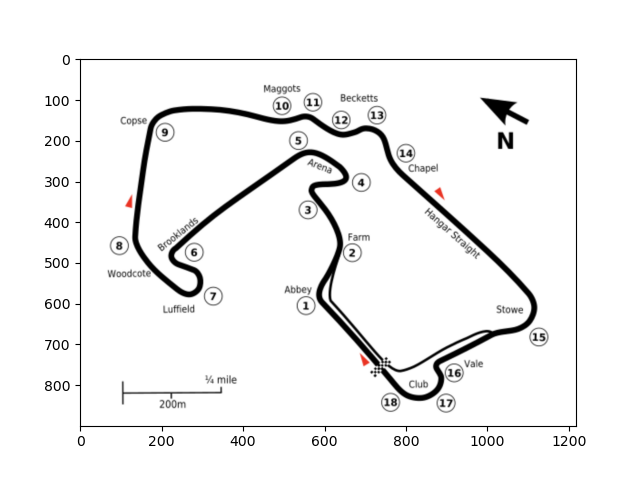

In [50]:
%matplotlib widget

points = []

img = plt.imread("silverstone.png")

fig, ax = plt.subplots()
ax.imshow(img)

def onclick(event):
    if event.xdata is not None and event.ydata is not None:
        points.append((event.xdata, event.ydata))
        ax.plot(event.xdata, event.ydata, 'ro')
        fig.canvas.draw()

cid = fig.canvas.mpl_connect('button_press_event', onclick)

plt.show()

In [82]:
points

array([[ 733.73790323,  753.01774194],
       [ 701.81451613,  716.18306452],
       [ 667.43548387,  679.3483871 ],
       [ 630.60080645,  640.05806452],
       [ 598.67741935,  605.67903226],
       [ 591.31048387,  593.40080645],
       [ 588.85483871,  576.21129032],
       [ 591.31048387,  556.56612903],
       [ 606.04435484,  536.92096774],
       [ 615.86693548,  517.27580645],
       [ 625.68951613,  497.63064516],
       [ 633.05645161,  480.44112903],
       [ 637.96774194,  455.88467742],
       [ 633.05645161,  428.87258065],
       [ 625.68951613,  406.77177419],
       [ 610.95564516,  384.67096774],
       [ 596.22177419,  362.57016129],
       [ 579.03225806,  345.38064516],
       [ 571.66532258,  330.64677419],
       [ 571.66532258,  315.91290323],
       [ 579.03225806,  308.54596774],
       [ 601.13306452,  306.09032258],
       [ 625.68951613,  306.09032258],
       [ 642.87903226,  293.81209677],
       [ 650.24596774,  276.62258065],
       [ 637.96774194,  2

Now we convert the clicked points into x and y arrays

In [83]:
points = np.array(points)
x = points[:,0]
y = points[:,1]

Turn the clicked points into a distance-based paramterization of the track (essential giving us the ability to take an s variable for distance along any point of the track and spit out an x and y value for that distance)

In [84]:
x_closed = np.append(x, x[0])
y_closed = np.append(y, y[0])

ds = np.sqrt(np.diff(x_closed)**2 + np.diff(y_closed)**2)
s = np.concatenate([[0], np.cumsum(ds)])

Now we build a smooth track from these points by fitting a subic curve to each pair.This ensures smoothness and give continuous positions, slopes, and curvature.

In [85]:
x_spline = CubicSpline(s, x_closed, bc_type='periodic')
y_spline = CubicSpline(s, y_closed, bc_type='periodic')

Below we visualize the track using our parameterized points

/var/folders/d1/vrysq4bx4hx0b4cnbfmzcdr40000gn/T/ipykernel_30003/4142020059.py:6: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(8,6))


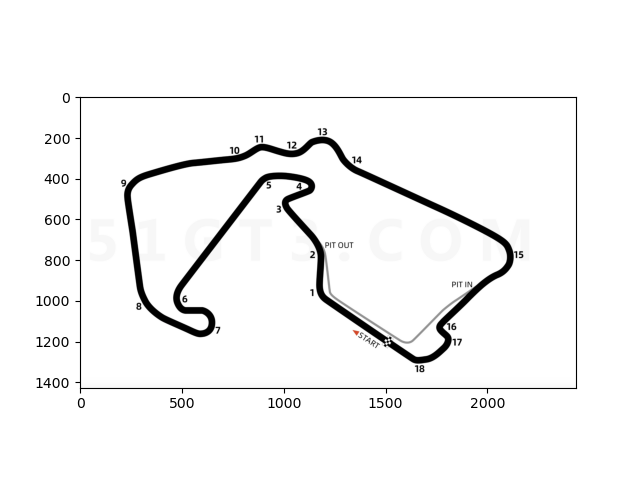

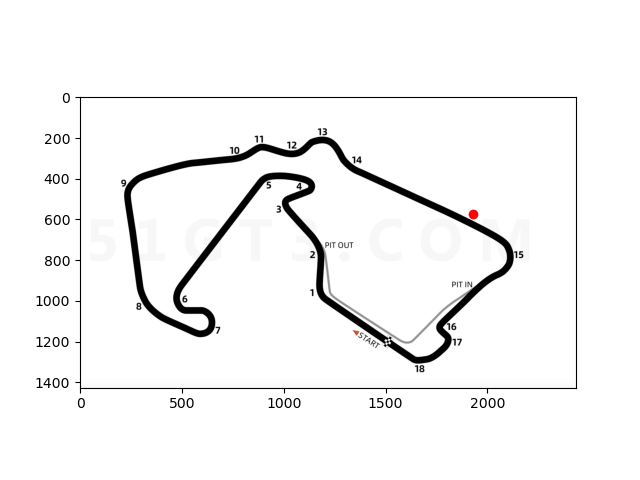

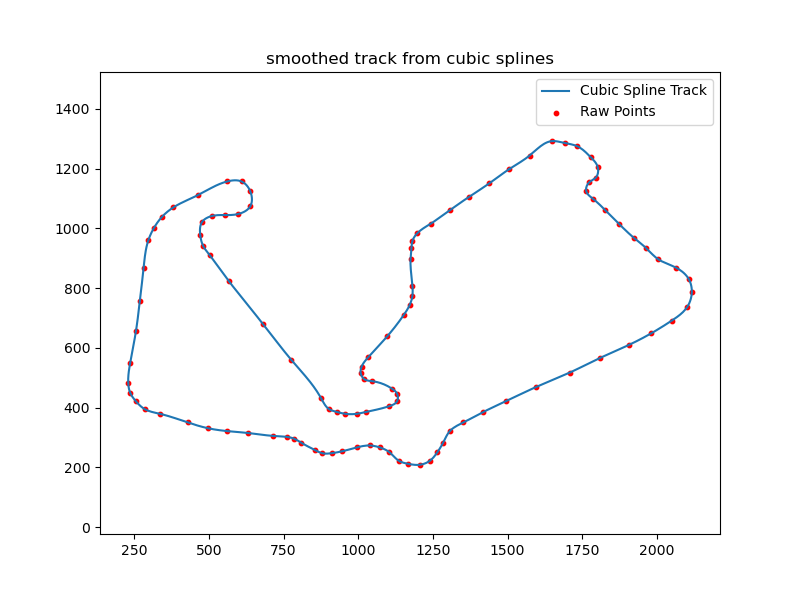

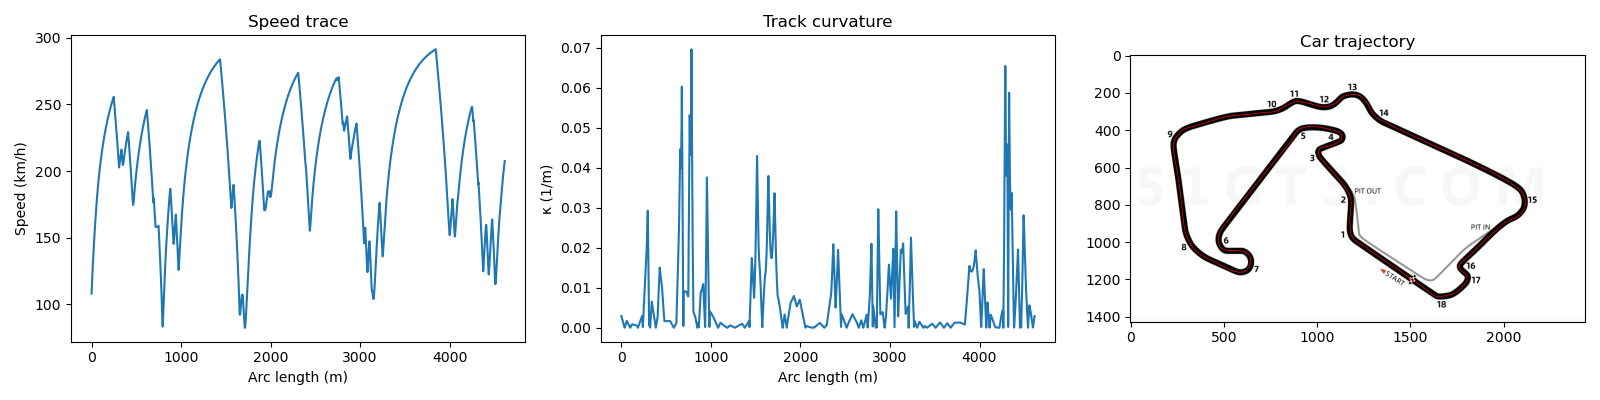

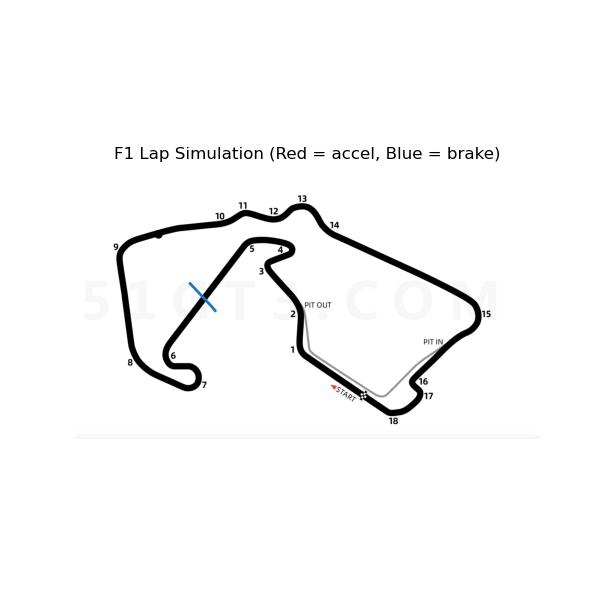

/var/folders/d1/vrysq4bx4hx0b4cnbfmzcdr40000gn/T/ipykernel_30003/4142020059.py:13: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


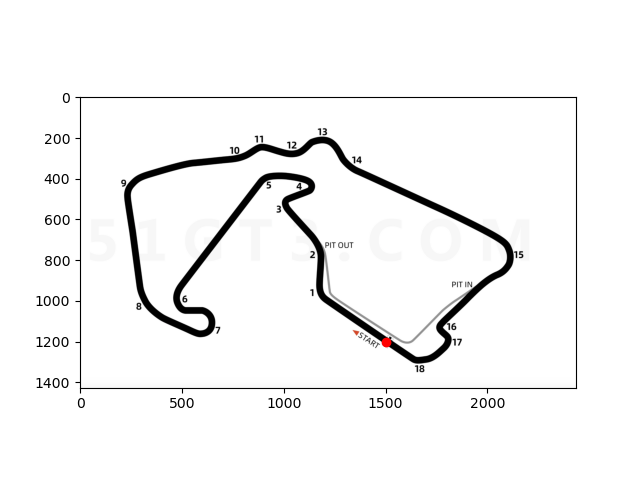

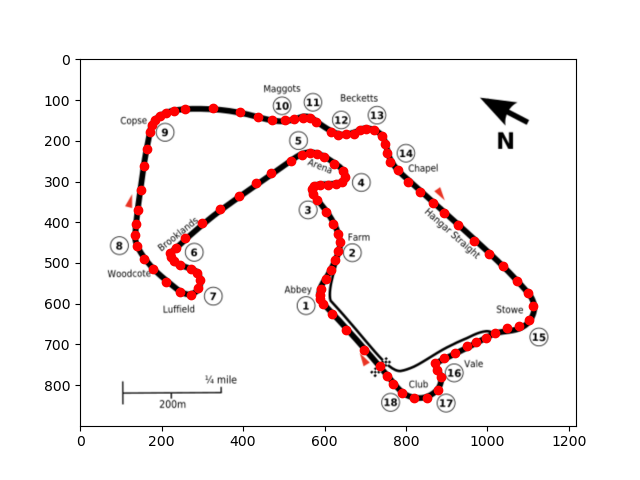

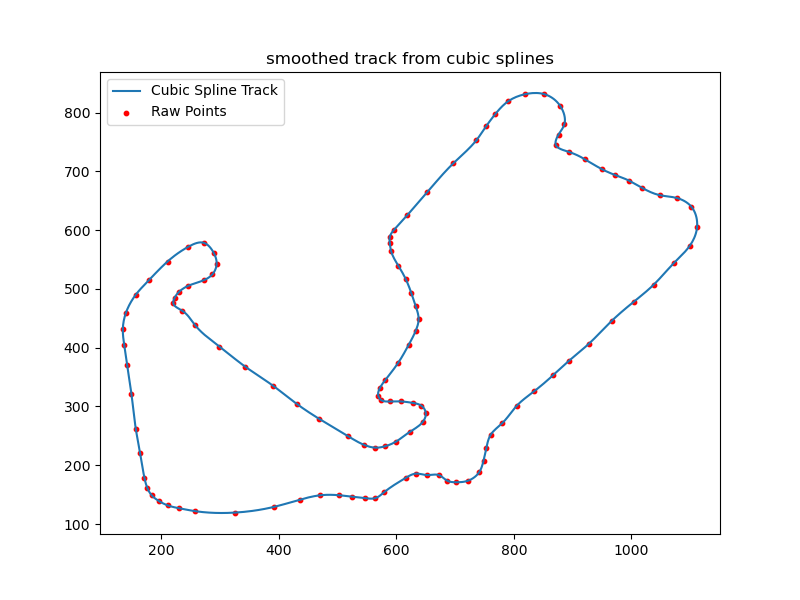

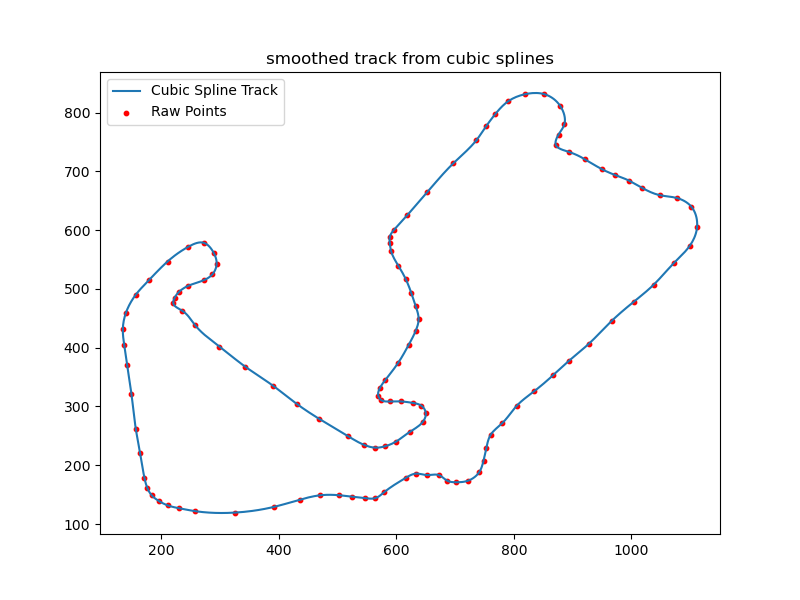

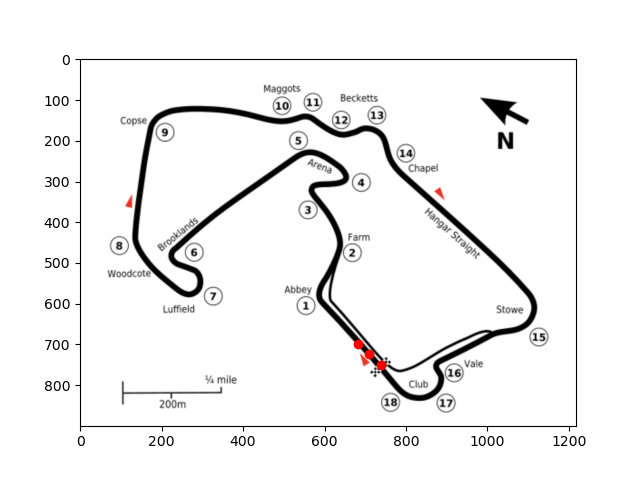

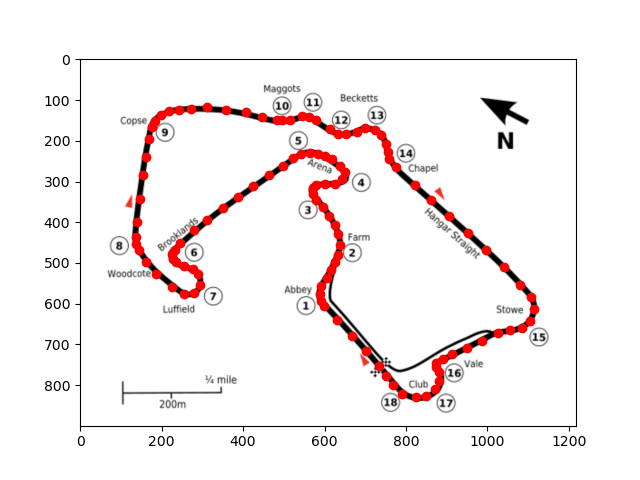

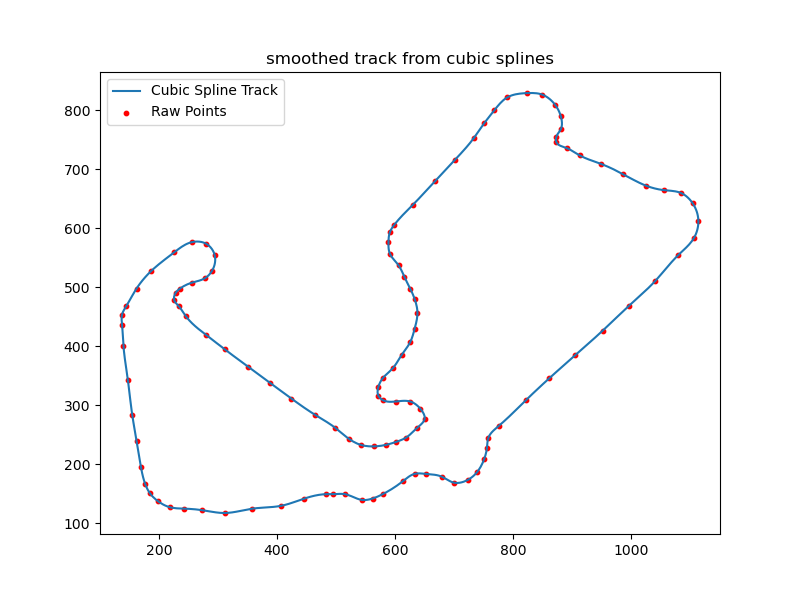

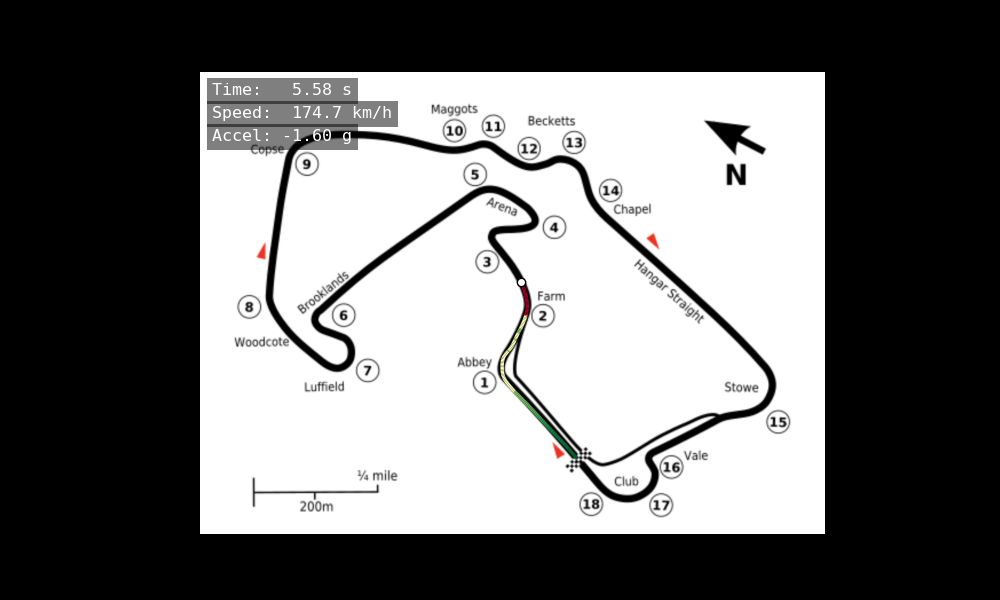

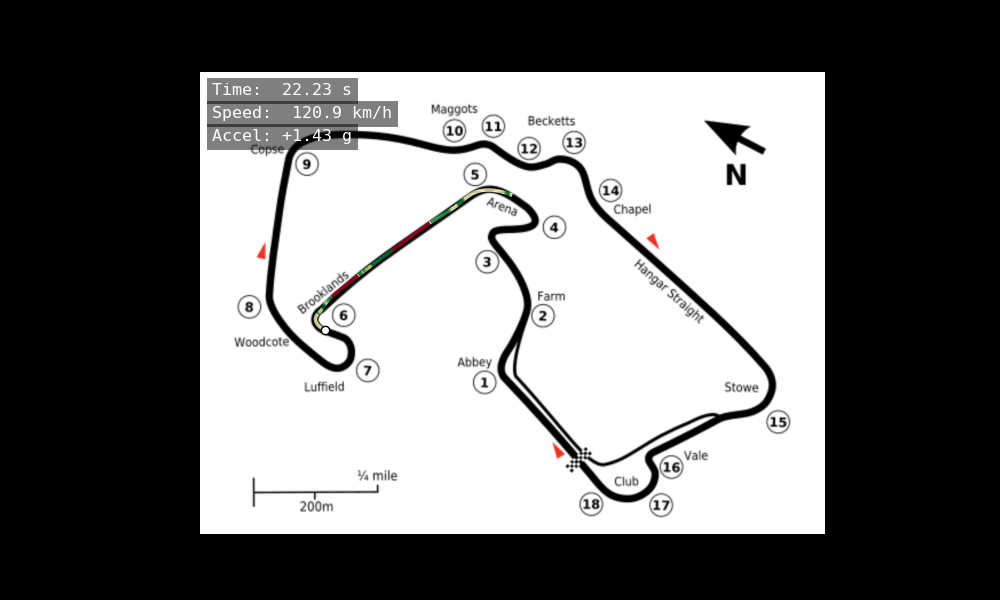

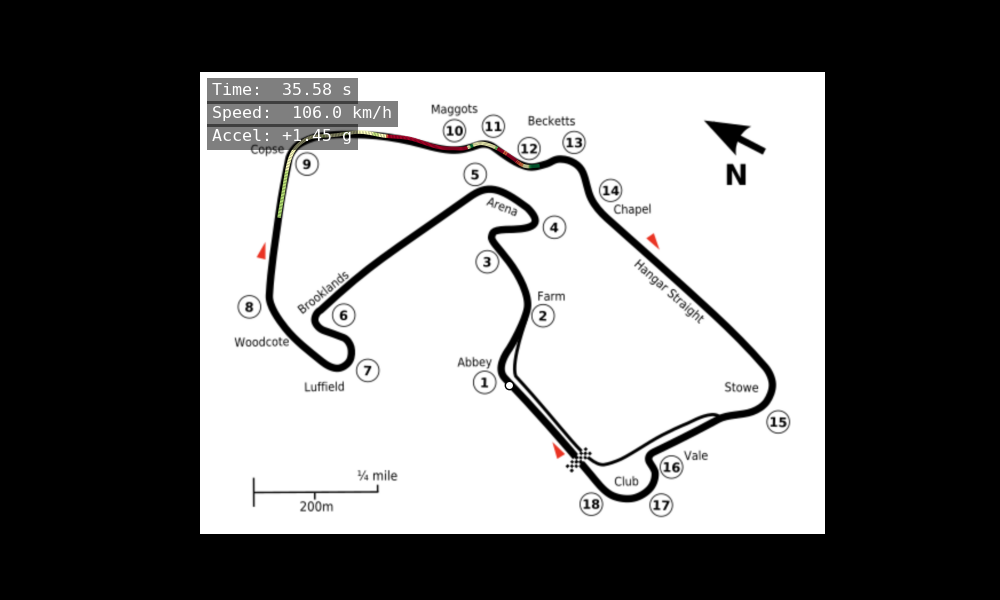

In [86]:
s_fine = np.linspace(0, s[-1], 1000)

x_smooth = x_spline(s_fine)
y_smooth = y_spline(s_fine)

plt.figure(figsize=(8,6))
plt.plot(x_smooth, y_smooth, label="Cubic Spline Track")
plt.scatter(x, y, s=10, color='red', label="Raw Points")

plt.axis("equal")
plt.legend()
plt.title("smoothed track from cubic splines")
plt.show()

Here i attempt to calculate some sort of scale so we can base the image in some sort of physical reality.

In [87]:
PIT_STRAIGHT_PIXELS = 620   # <-- This is a rough estimate maybe come back here
PIT_STRAIGHT_METRES = 450
SCALE = PIT_STRAIGHT_METRES / PIT_STRAIGHT_PIXELS  # metres per pixel
x_m = x_closed * SCALE
y_m = y_closed * SCALE

Compute distances again this time in meters and then a vector s with the cumulative distances between each consecutive point

In [88]:
ds = np.sqrt(np.diff(x_m)**2 + np.diff(y_m)**2)
s = np.concatenate([[0], np.cumsum(ds)])
s = np.maximum.accumulate(s)

Build cubic spline again and get track length (last element of s)

In [89]:
x_spline = CubicSpline(s, x_m, bc_type='periodic')
y_spline = CubicSpline(s, y_m, bc_type='periodic')

track_length = s[-1]

We begin by calculating curvature: $\kappa(s)=\frac{|x'(s)y''(s)-y'(s)x''(s)|}{(x'(s)^2+y'(s)^2)^{3/2}}$. The intution behind this formula is that a straight line would imply $\kappa=0$ due to second derivatives being 0. A gentle curve would be a small $\kappa$ and a tight corner would be a large $\kappa$. Last line of the following code turns it into a function that we can call on any s.

In [90]:
s_fine = np.linspace(0, track_length, 5000)

dx  = x_spline(s_fine, 1)
dy  = y_spline(s_fine, 1)
ddx = x_spline(s_fine, 2)
ddy = y_spline(s_fine, 2)

kappa = np.abs(dx * ddy - dy * ddx) / (dx**2 + dy**2)**1.5
kappa = gaussian_filter1d(kappa, sigma=3)
kappa_fn = interp1d(s_fine, kappa, bounds_error=False, fill_value=1e-6)

Physical constants for force calculations: (maybe we should vary these and see how the output changes)

In [91]:
m    = 740.0       # kg  car + driver
rho  = 1.225       # kg/m³ air density
C_d  = 0.9         # drag coefficient
A    = 1.5         # m²  frontal area
rr   = 0.02 * m * 9.81 / 100  # rolling resistance book uses Fr = rr*v
rr_beckman = 10.0  # N/(m/s)
g    = 9.81

P_engine = 560e3   # W  ~750 hp
v_min    = 5.0     # m/s  avoid F_W going to inf at v=0

mu_lat   = 1.8     # lateral friction (grip angle model from Part 10)
mu_long  = 1.6     # longitudinal friction

$v_{max}(s)=\sqrt{\frac{\mu_{lat}g}{\kappa(s)}}$ gives use the max cornering speed. We also turn this into a function on the second line

In [ ]:
v_max_corner = np.sqrt(mu_lat * g / np.maximum(kappa, 1e-6))
v_corner_fn  = interp1d(s_fine, v_max_corner, bounds_error=False, fill_value=np.inf)

This function computes the car's acceleration while respecting physical constants like engine power, tire grip etc. all defined above. $a_{long}=\frac{F_W-F_d-F_r}{m}$, engine pushed forward, drag + rolling resist backward. $a_{lat}=v^2\kappa$ which is centripetal acceleration. Also, we define $a_{lat}^2+a_{long}\le(\mu g)^2$

In [92]:
def forces(s_pos, v):
    v     = float(max(v, v_min))
    F_d   = 0.5 * rho * C_d * A * v**2
    F_r   = rr_beckman * v
    F_W   = min(P_engine / v, mu_long * m * g)
    F_net = F_W - F_d - F_r
    a_long = F_net / m
    kappa_val   = float(kappa_fn(float(s_pos) % track_length))
    a_lat        = v**2 * kappa_val
    a_lat_clamped = min(a_lat, mu_lat * g)
    a_long_max   = np.sqrt(max((mu_long * g)**2 - a_lat_clamped**2, 0))
    return float(np.clip(a_long, -mu_long * g, a_long_max))

Now let's set up a state vector $\begin{bmatrix} s \\ v \end{bmatrix}$ which encomposses position and velocity. We will be integrating this via RK4

In [97]:
def f(t, y):
    s_pos, v = float(y[0]), float(y[1])
    v = max(v, 0.0)
    v_cap = float(v_corner_fn(s_pos % track_length))
    a = -mu_long * g if v > v_cap else forces(s_pos, v)
    return np.array([v, a], dtype=float)

Standard RK4 ODE solver

In [98]:
def rk4_step(f, t, y, h):
    k1 = f(t,       y)
    k2 = f(t + h/2, y + h/2 * k1)
    k3 = f(t + h/2, y + h/2 * k2)
    k4 = f(t + h,   y + h   * k3)
    return y + (h / 6.0) * (k1 + 2*k2 + 2*k3 + k4)

Here we have the main simulation loop. We start with an initial state of $\begin{bmatrix} 0 \\ 30 \end{bmatrix}$. We simulate until s > track lenght (we've reach end of track). For each time step we use RK4 to solve $\frac{d}{dt}\begin{bmatrix} s \\ v \end{bmatrix}=\begin{bmatrix} v \\ a(s,v) \end{bmatrix}$ by sampling the derivative multiple times (RK4). So at each time step we record, where the car is, how fast its going, and when it happens.

In [99]:
h = 0.01
t = 0.0
y_state = np.array([0.0, 30.0])
 
t_hist, s_hist, v_hist = [t], [y_state[0]], [y_state[1]]
 
while y_state[0] < track_length:
    y_state = rk4_step(f, t, y_state, h)
    t += h
    t_hist.append(t)
    s_hist.append(y_state[0])
    v_hist.append(y_state[1])
 
t_hist = np.array(t_hist)
s_hist = np.array(s_hist)
v_hist = np.array(v_hist)

We use numerical differentiation to look at slope of velocity curve to give acceleration over time.

In [100]:
a_hist = np.gradient(v_hist, t_hist)

Convert track position back into 2d coords so we can visualize

In [101]:
s_wrapped = s_hist % track_length
x_car = x_spline(s_wrapped) / SCALE
y_car = y_spline(s_wrapped) / SCALE

FROM HERE ON OUT IS CODE FOR THE FULL VIDEO SIMULATION OF OUR RESULTS:

Below is just RK4 again

In [102]:
h = 0.01
t = 0.0
y_state = np.array([0.0, 30.0])
t_hist, s_hist, v_hist = [t], [y_state[0]], [y_state[1]]
last_pct = -1
 
while y_state[0] < track_length:
    y_state = rk4_step(f, t, y_state, h)
    t += h
    t_hist.append(t)
    s_hist.append(float(y_state[0]))
    v_hist.append(float(y_state[1]))
    pct = int(100 * y_state[0] / track_length)
    if pct != last_pct and pct % 10 == 0:
        print(f"  {pct}%  (t={t:.1f}s)")
        last_pct = pct
    if len(t_hist) > 1_000_000:
        print("ERROR: simulation did not finish. Check PIT_STRAIGHT_PIXELS and your x/y points.")
        raise SystemExit(1)
 
t_arr = np.array(t_hist)
s_arr = np.array(s_hist)
v_arr = np.array(v_hist)
a_arr = np.gradient(v_arr, t_arr)

  0%  (t=0.0s)
  10%  (t=4.7s)
  20%  (t=10.1s)
  30%  (t=15.8s)
  40%  (t=23.2s)
  50%  (t=27.6s)
  60%  (t=31.4s)
  70%  (t=39.5s)
  80%  (t=44.7s)
  90%  (t=48.7s)
  100%  (t=54.1s)


1D simulation to 2D

In [103]:
s_wrapped = s_arr % track_length
x_car = x_spline(s_wrapped) / SCALE
y_car = y_spline(s_wrapped) / SCALE

Next we convert simulation into video-friendly 30 fps

In [104]:
TARGET_FPS = 30
dt_sim = float(np.mean(np.diff(t_arr)))
step = max(1, int(round(1.0 / (TARGET_FPS * dt_sim))))
idx = np.arange(0, len(t_arr), step)

t_anim = t_arr[idx]
v_anim = v_arr[idx]
a_anim = a_arr[idx]
x_anim = x_car[idx]
y_anim = y_car[idx]
N = len(idx)

Set up the track

In [105]:
img = plt.imread("silverstone.png")
H, W = img.shape[:2]

fig, ax_map = plt.subplots(figsize=(10, 6), dpi=100)
fig.patch.set_facecolor("black")

ax_map.imshow(img)
ax_map.set_xlim(0, W)
ax_map.set_ylim(H, 0)
ax_map.axis("off")

(np.float64(0.0), np.float64(1218.0), np.float64(900.0), np.float64(0.0))

This sets up trail effect for the car, we'll see if it works

In [106]:
TRAIL_LEN = 300

norm_a = mcolors.TwoSlopeNorm(
    vmin=np.min(a_anim),
    vcenter=0,
    vmax=np.max(a_anim)
)
cmap_a = cm.RdYlGn

def make_segments(x, y):
    pts = np.array([x, y]).T.reshape(-1, 1, 2)
    return np.concatenate([pts[:-1], pts[1:]], axis=1)

trail_lc = LineCollection([], cmap=cmap_a, norm=norm_a, linewidth=2.5)
ax_map.add_collection(trail_lc)

car_dot, = ax_map.plot([], [], 'o',
                       color='white',
                       markersize=6,
                       markeredgecolor='black')

Text for time, velocity, and acceleration

In [107]:
time_text = ax_map.text(
    0.02, 0.95, "", transform=ax_map.transAxes,
    fontsize=12, color="white",
    bbox=dict(facecolor="black", alpha=0.5, edgecolor="none"),
    fontfamily="monospace"
)

speed_text = ax_map.text(
    0.02, 0.90, "", transform=ax_map.transAxes,
    fontsize=12, color="white",
    bbox=dict(facecolor="black", alpha=0.5, edgecolor="none"),
    fontfamily="monospace"
)

accel_text = ax_map.text(
    0.02, 0.85, "", transform=ax_map.transAxes,
    fontsize=12, color="white",
    bbox=dict(facecolor="black", alpha=0.5, edgecolor="none"),
    fontfamily="monospace"
)

This decides what happens for every frame (i.e. given frame i, update the car, trail, and numbers)

In [108]:
def update(i):
    start = max(0, i - TRAIL_LEN)

    xs = x_anim[start:i+1]
    ys = y_anim[start:i+1]
    ac = a_anim[start:i+1]

    if len(xs) >= 2:
        trail_lc.set_segments(make_segments(xs, ys))
        trail_lc.set_color(cmap_a(norm_a(ac[:-1])))
    else:
        trail_lc.set_segments([])

    car_dot.set_data([x_anim[i]], [y_anim[i]])

    # ── SIMPLE TEXT ──
    t = t_anim[i]
    v = v_anim[i]
    a = a_anim[i]

    time_text.set_text(f"Time: {t:6.2f} s")
    speed_text.set_text(f"Speed: {v*3.6:6.1f} km/h")
    accel_text.set_text(f"Accel: {a/9.81:+.2f} g")

    return trail_lc, car_dot, time_text, speed_text, accel_text

Make the video. ONLY RUN THIS BLOCK IF YOU WANT TO CREATE AND SAVE THE VIDEO

In [109]:
anim = FuncAnimation(
    fig,
    update,
    frames=N,
    interval=1000 / TARGET_FPS,
    blit=True
)

writer = FFMpegWriter(
    fps=TARGET_FPS,
    bitrate=3000,
    extra_args=['-vcodec', 'libx264', '-pix_fmt', 'yuv420p']
)

anim.save("simple_track_video.mp4", writer=writer, dpi=100)

print("Saved")
 

KeyboardInterrupt: 